# NOTEBOOK: Linear Regression

 Goal: Implement and evaluate Linear Regression

## Setup

In [9]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_target_relationships
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnLinearRegression
from src.models.unsupervised import SKLearnPCA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 1460 rows × 80 columns

Data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Length: 80, dtype: object

Missing values:
              Missing_Count  Missing_Percent
PoolQC                 1453            99.52
MiscFeature            1406            96.30
Alley                  1369            93.77
Fence                  1179            80.75
FireplaceQu             690            47.26
LotFrontage             259            17.74
GarageType               81             5.55
GarageYrBlt              81             5.55
GarageFinish             81             5.55
GarageQual               81             5.55
GarageCond               81             5.55
BsmtExposure             38             2.60
BsmtFinType2             38    

/Users/cdubois/workshop/ml-fundamentals/src/eda.py:545: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/cdubois/workshop/ml-fundamentals/src/eda.py:552: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


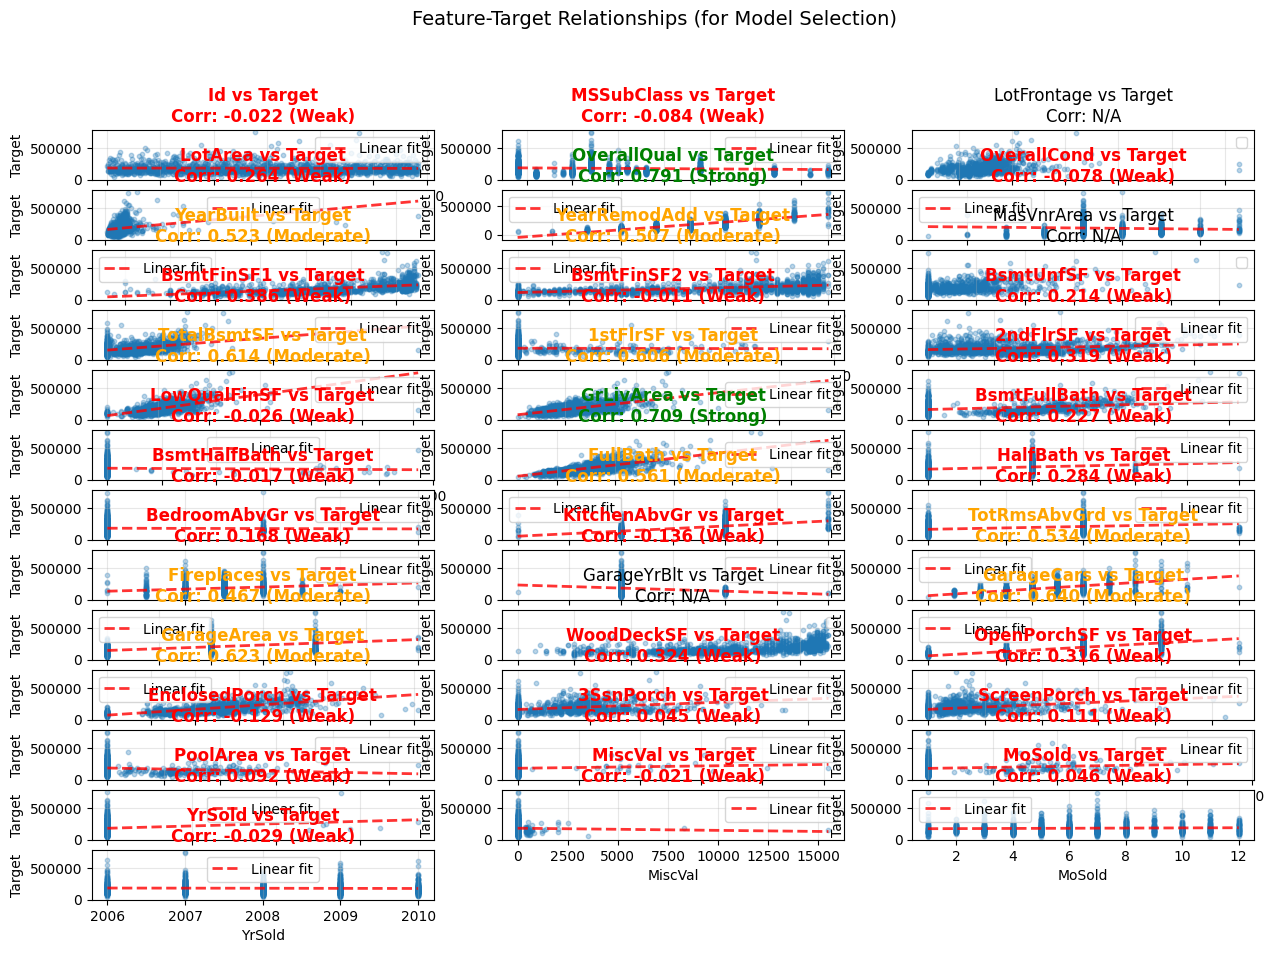

In [2]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_ames_housing()

analyze_data(X, show_stats=True)
plot_feature_target_relationships(X, y)

## Preprocess Data

In [3]:


# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 37 columns
   Nominal categorical: 43 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 43 nominal columns...
   → Created 250 one-hot features

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 37 features

Final shape: 1168 rows × 287 features

Training set: (1168, 287)
Test set: (292, 287)

Feature names after preprocessing:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'Open

## Model Training

In [4]:
model = SKLearnLinearRegression()
model.fit(X_train_proc, y_train)

print("✓ Model trained successfully")

✓ Model trained successfully


## Model Evaluation & Diagnostics


MODEL EVALUATION
R² Score: 0.8869
RMSE: 29448.4894
MAE: 18360.0278


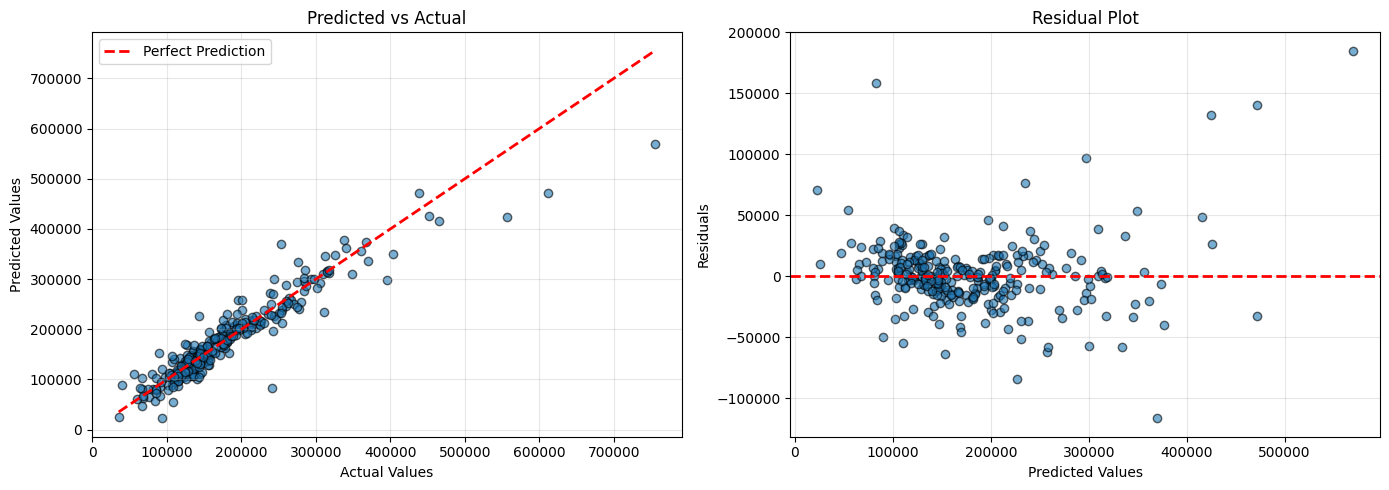

In [ ]:
y_pred = model.predict(X_test_proc)
r2 = model.score(X_test_proc, y_test)
rmse = np.sqrt(model.mean_squared_error(X_test_proc, y_test))
mae = model.mean_absolute_error(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

if r2 >= 0.90:
    print("\n💡 Excellent performance (R² ≥ 0.90)")
elif r2 >= 0.75:
    print("\n💡 Good performance (R² ≥ 0.75)")
elif r2 >= 0.60:
    print("\n💡 Moderate performance (R² ≥ 0.60)")
else:
    print("\n💡 Room for improvement (R² < 0.60)")
    
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 How to interpret:")
print("   • Predicted vs Actual: Points close to red line = good predictions")
print("   • Residual Plot: Random scatter around zero = good model fit")
print("   • Patterns in residuals = model is missing something")

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1168

Fold 1/5: r2=0.8589 (train: 934, test: 234)
Fold 2/5: r2=0.7492 (train: 934, test: 234)
Fold 3/5: r2=0.6542 (train: 934, test: 234)
Fold 4/5: r2=0.8682 (train: 935, test: 233)
Fold 5/5: r2=0.7098 (train: 935, test: 233)

CROSS-VALIDATION RESULTS
Mean r2: 0.7681 ± 0.0836
Min r2:  0.6542
Max r2:  0.8682


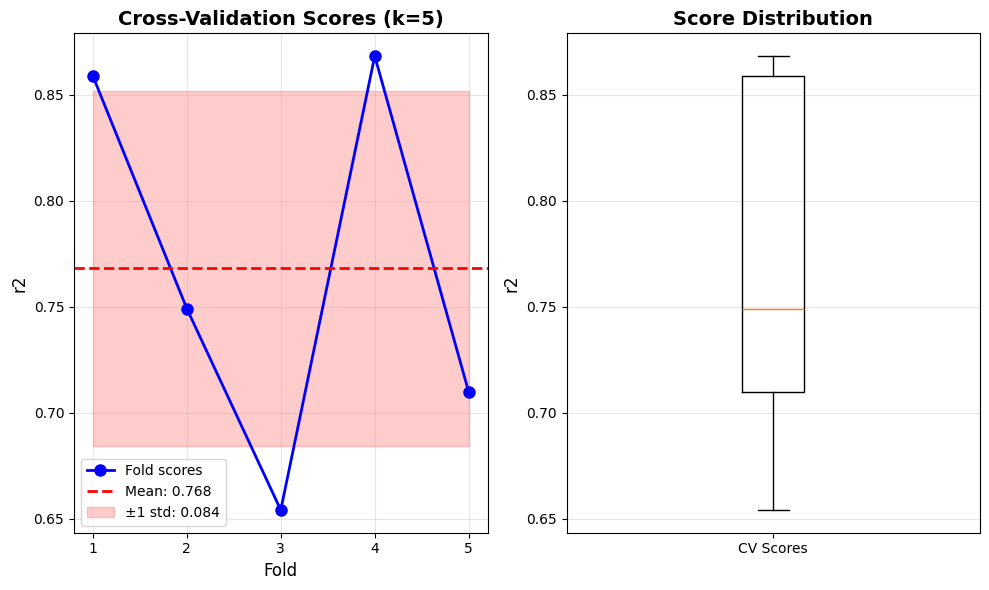


💡 Cross-validation provides more reliable estimate:
   Single test split: 0.8869
   5-fold CV: 0.7681 ± 0.0836


In [7]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_results = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='r2'
)

# Visualize
plot_cross_validation_results(cv_results)

print(f"\n💡 Cross-validation provides more reliable estimate:")
print(f"   Single test split: {r2:.4f}")
print(f"   5-fold CV: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")

## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA PROJECTION - REGRESSION
Target range: [34900.00, 745000.00]
💡 Color intensity = target value magnitude
   • Darker colors = lower values
   • Lighter colors = higher values
   Look for patterns: Do similar values cluster together?


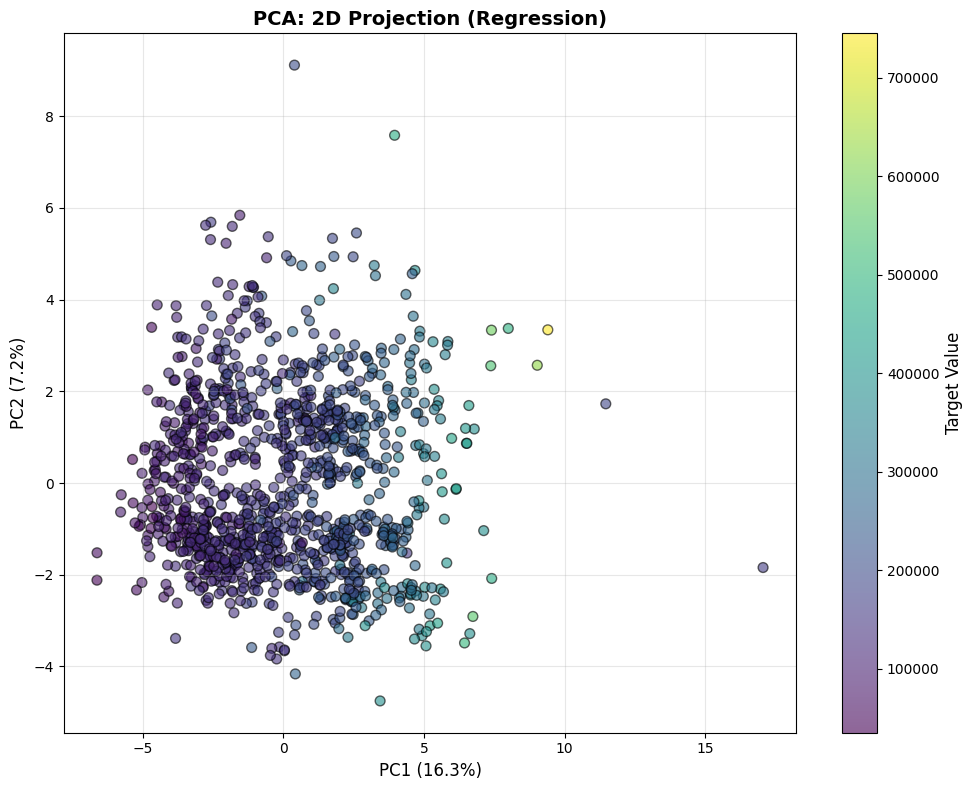


Variance explained:
  PC1: 16.3%
  PC2: 7.2%
  Total: 23.6%


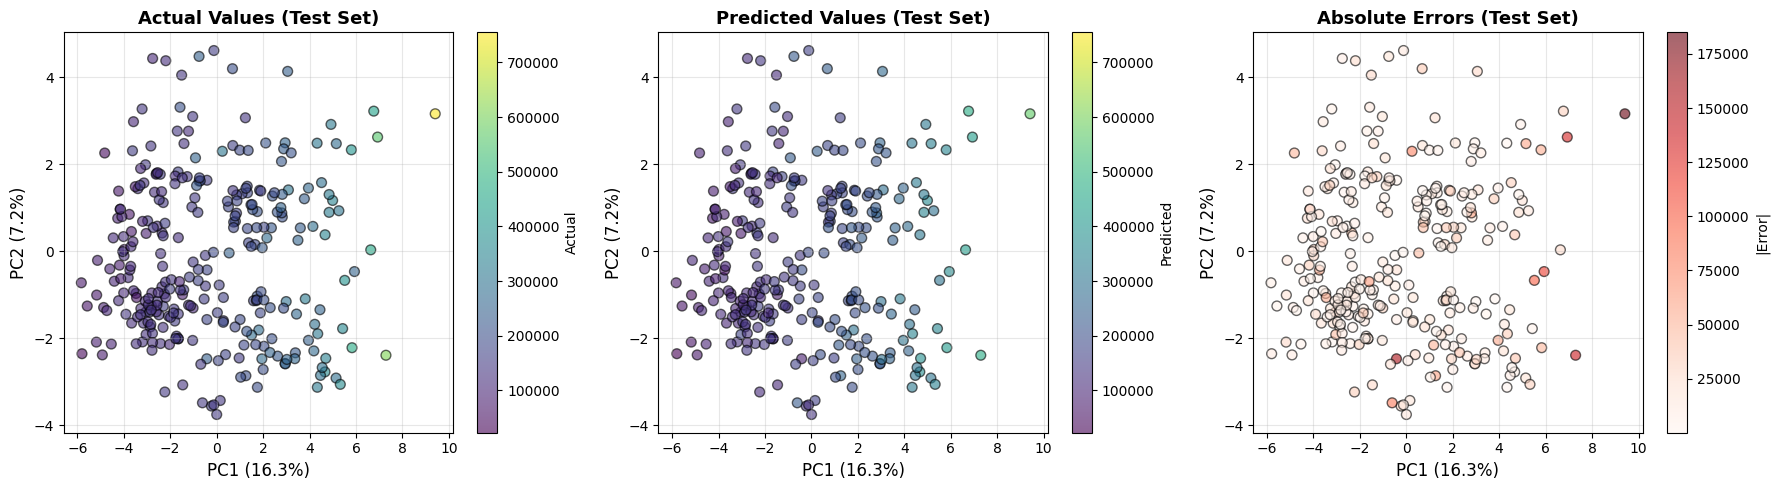


REGRESSION PROJECTION ANALYSIS

Target range: [22596.34, 755000.00]
Mean absolute error: 18360.03
Max absolute error: 184944.79

💡 Interpretation:
   • Similar colors (left vs middle) → Good predictions
   • Different colors → Prediction errors
   • Red areas (right plot) → High error regions
   • Look for spatial patterns: Are errors clustered?


In [12]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

pca = SKLearnPCA(n_components=2)
pca.fit(X_train_proc)
pca.plot_2d_projection(X_train_proc, y_train, task='regression')
pca.plot_regression_projection_with_predictions(
    X_test_proc, y_test, y_pred, 
    title_suffix="Test Set"
)

## Feature Analysis


FEATURE IMPORTANCE (Coefficients)

Analyzing 287 coefficients


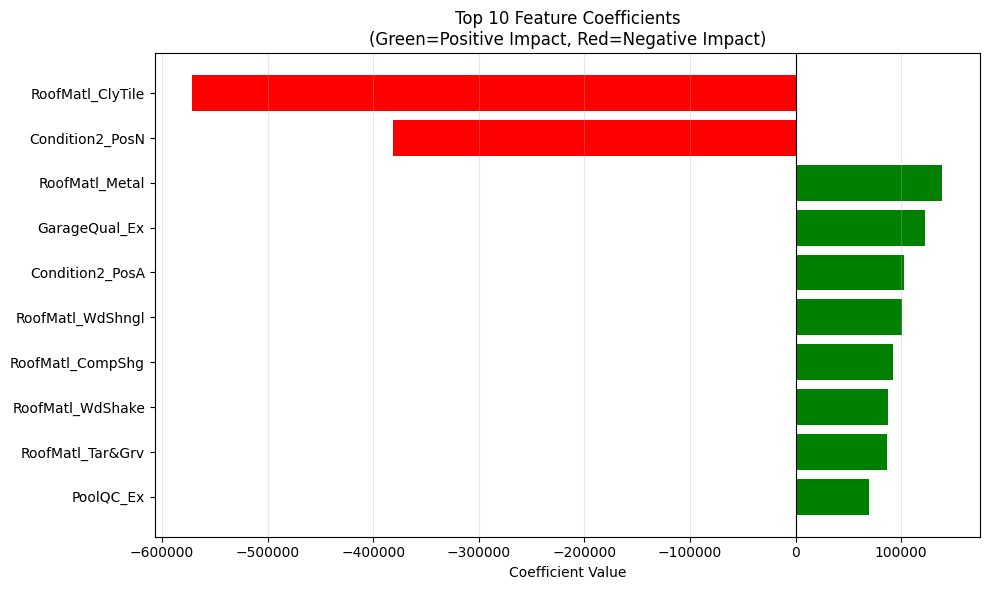


💡 Coefficient interpretation:
   • Positive: Feature increase → higher probability of class 1
   • Negative: Feature increase → lower probability of class 1
   • Larger magnitude: Stronger influence

Top 5 most important features:
  • RoofMatl_ClyTile: -571500.7279 (decreases survival probability)
  • Condition2_PosN: -381739.2948 (decreases survival probability)
  • RoofMatl_Metal: +139143.7434 (increases survival probability)
  • GarageQual_Ex: +122408.0405 (increases survival probability)
  • Condition2_PosA: +102765.6410 (increases survival probability)


In [13]:
if hasattr(model, 'coef_'):
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (Coefficients)")
    print("="*70)
    
    coefs = model.coef_
    if len(coefs.shape) > 1:
        coefs = coefs[0]
    
    # Get feature names from preprocessor
    feature_names = preprocessor.get_feature_names()
    
    print(f"\nAnalyzing {len(coefs)} coefficients")
    
    # Sort by absolute value
    abs_coefs = np.abs(coefs)
    top_n = min(10, len(coefs))
    indices = np.argsort(abs_coefs)[-top_n:]
    
    # Plot
    plt.figure(figsize=(10, 6))
    colors = ['red' if coefs[i] < 0 else 'green' for i in indices]
    plt.barh(range(len(indices)), coefs[indices], color=colors)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Coefficient Value')
    plt.title(f'Top {top_n} Feature Coefficients\n(Green=Positive Impact, Red=Negative Impact)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Coefficient interpretation:")
    print("   • Positive: Feature increase → higher probability of class 1")
    print("   • Negative: Feature increase → lower probability of class 1")
    print("   • Larger magnitude: Stronger influence")
    
    # Show top coefficients
    print(f"\nTop {min(5, top_n)} most important features:")
    for idx in indices[::-1][:5]:
        direction = "increases" if coefs[idx] > 0 else "decreases"
        print(f"  • {feature_names[idx]}: {coefs[idx]:+.4f} ({direction} survival probability)")

## Key Insights & Summary

In [14]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\n✓ Model: {model.__class__.__name__}")
print(f"✓ Test R²: {r2:.4f}")
print(f"✓ Test RMSE: {rmse:.4f}")
print(f"✓ CV R²: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")
print(f"\n💡 Model explains {r2*100:.1f}% of variance in target")
print(f"\n💡 When to use Linear Regression:")
print("   • Linear relationship between features and target")
print("   • Need interpretable coefficients")
print("   • Baseline model for comparison")
print("   • Fast training and prediction required")

print(f"\n💡 Next Steps:")
if r2 < 0.70:  # Adjust threshold as needed
    print("   • Try more complex models (Random Forest, SVM)")
    print("   • Feature engineering (polynomial features, interactions)")
    print("   • Collect more data")
    print("   • Check for data quality issues")
else:
    print("   • Model performs well!")
    print("   • Consider deployment")
    print("   • Monitor performance on new data")


KEY INSIGHTS

✓ Model: SKLearnLinearRegression
✓ Test R²: 0.8869
✓ Test RMSE: 29448.4894
✓ CV R²: 0.7681 ± 0.0836

💡 Model explains 88.7% of variance in target

💡 When to use Linear Regression:
   • Linear relationship between features and target
   • Need interpretable coefficients
   • Baseline model for comparison
   • Fast training and prediction required

💡 Next Steps:
   • Model performs well!
   • Consider deployment
   • Monitor performance on new data
